<a href="https://colab.research.google.com/github/mhtuhin0fficialg-source/CICIoMT2024.ipynb/blob/main/CICIoMT2024_(12).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "CICFlow" in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/CICIoMT2024/CICIoMT2024_labelled_CICFlow.csv


In [3]:
import pandas as pd

file_path = "/content/drive/MyDrive/CICIoMT2024/CICIoMT2024_labelled_CICFlow.csv"

df = pd.read_csv(file_path, nrows=50000)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 87)


,Unnamed: 0,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Class,Sub-Class
0,0,192.168.137.174-52.27.132.196-36954-443-6,192.168.137.174,36954,52.27.132.196,443,6,05/09/2023 08:38:22 AM,609760,41,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Attack,DDoS,DDoS-SYN
1,1,192.168.137.48-192.168.137.140-1621-6668-6,192.168.137.48,1621,192.168.137.140,6668,6,05/09/2023 08:38:38 AM,55193,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Attack,DDoS,DDoS-SYN
2,2,192.168.137.48-192.168.137.140-1620-6668-6,192.168.137.48,1620,192.168.137.140,6668,6,05/09/2023 08:38:38 AM,55163,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Attack,DDoS,DDoS-SYN
3,3,192.168.137.48-192.168.137.140-1623-6668-6,192.168.137.48,1623,192.168.137.140,6668,6,05/09/2023 08:38:38 AM,58598,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Attack,DDoS,DDoS-SYN
4,4,192.168.137.48-192.168.137.140-1622-6668-6,192.168.137.48,1622,192.168.137.140,6668,6,05/09/2023 08:38:38 AM,59194,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Attack,DDoS,DDoS-SYN


In [4]:
print("Rows:", df.shape[0])
print("Columns/features:", df.shape[1])
print(df.columns.tolist())

Rows: 50000
Columns/features: 87
['Unnamed: 0', 'Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST F

In [5]:
for col in df.columns:
    if "label" in col.lower() or "attack" in col.lower() or "class" in col.lower() or "category" in col.lower():
        print("Possible label column:", col)
        print(df[col].value_counts().head(20))
        print()

Possible label column: Label
Label
Attack    50000
Name: count, dtype: int64

Possible label column: Class
Class
DDoS    50000
Name: count, dtype: int64

Possible label column: Sub-Class
Sub-Class
DDoS-SYN    50000
Name: count, dtype: int64



In [6]:
import pandas as pd
import random

file_path = "/content/drive/MyDrive/CICIoMT2024/CICIoMT2024_labelled_CICFlow.csv"

# First, count total rows approximately
with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    total_rows = sum(1 for line in f) - 1

print("Total rows:", total_rows)

# Randomly select 100,000 rows
sample_size = 100000
skip_rows = sorted(random.sample(range(1, total_rows + 1), total_rows - sample_size))

df = pd.read_csv(file_path, skiprows=skip_rows)

print("Sample shape:", df.shape)
print(df["Label"].value_counts())
print(df["Class"].value_counts())
print(df["Sub-Class"].value_counts().head(20))

Total rows: 7927543
Sample shape: (100000, 87)
Label
Attack    100000
Name: count, dtype: int64
Class
DDoS     63163
DoS      21391
MQTT     10295
Recon     5151
Name: count, dtype: int64
Sub-Class
DDoS-SYN          63142
DoS-SYN           13783
DDoS-Connected    10295
DoS-TCP            7415
Port-Scan          4863
OS-Scan             203
DoS-UDP             179
Vuln-Scan            85
DDoS-IMCP            21
DoS-IMCP             14
Name: count, dtype: int64


In [7]:
target_column = "Class"

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [9]:
target_column = "Class"

drop_columns = [
    "Label",
    "Class",
    "Sub-Class",
    "Timestamp",
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Unnamed: 0"
]

X = df.drop(columns=[col for col in drop_columns if col in df.columns])
y = df[target_column]

X = pd.get_dummies(X)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Feature shape:", X.shape)
print("Classes:", le.classes_)

Feature shape: (100000, 79)
Classes: ['DDoS' 'DoS' 'MQTT' 'Recon']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (80000, 79)
Test: (20000, 79)


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 0.9992
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     12633
         DoS       1.00      1.00      1.00      4278
        MQTT       1.00      1.00      1.00      2059
       Recon       1.00      1.00      1.00      1030

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "CICFlow" in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/CICIoMT2024/CICIoMT2024_labelled_CICFlow.csv


In [14]:
import pandas as pd

file_path = "/content/drive/MyDrive/CICIoMT2024/CICIoMT2024_labelled_CICFlow.csv"

df = pd.read_csv(file_path, nrows=1000000)

print("Dataset shape:", df.shape)
print(df["Class"].value_counts())
print(df["Sub-Class"].value_counts().head(20))

Dataset shape: (1000000, 87)
Class
DDoS    1000000
Name: count, dtype: int64
Sub-Class
DDoS-SYN    1000000
Name: count, dtype: int64


In [15]:
import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/CICIoMT2024/CICIoMT2024_labelled_CICFlow.csv"

target_sample_size = 1000000
total_rows = 7927543
sample_fraction = target_sample_size / total_rows

chunksize = 250000
sample_parts = []

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunksize)):
    n_sample = int(len(chunk) * sample_fraction)

    if n_sample > 0:
        sampled_chunk = chunk.sample(n=n_sample, random_state=42+i)
        sample_parts.append(sampled_chunk)

    print(f"Processed chunk {i+1}")

df_mixed = pd.concat(sample_parts, ignore_index=True)

# Combine all sampled chunks
df_mixed = pd.concat(sample_parts, ignore_index=True)

# Shuffle all available rows
df_mixed = df_mixed.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Mixed dataset shape:", df_mixed.shape)
print("\nClass distribution:")
print(df_mixed["Class"].value_counts())
print("Mixed dataset shape:", df_mixed.shape)
print(df_mixed["Class"].value_counts())
print(df_mixed["Sub-Class"].value_counts().head(20))

Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9
Processed chunk 10
Processed chunk 11
Processed chunk 12
Processed chunk 13
Processed chunk 14
Processed chunk 15
Processed chunk 16
Processed chunk 17
Processed chunk 18
Processed chunk 19
Processed chunk 20
Processed chunk 21
Processed chunk 22
Processed chunk 23
Processed chunk 24
Processed chunk 25
Processed chunk 26
Processed chunk 27
Processed chunk 28
Processed chunk 29
Processed chunk 30
Processed chunk 31
Processed chunk 32
Mixed dataset shape: (999980, 87)

Class distribution:
Class
DDoS     630856
DoS      215141
MQTT     103154
Recon     50829
Name: count, dtype: int64
Mixed dataset shape: (999980, 87)
Class
DDoS     630856
DoS      215141
MQTT     103154
Recon     50829
Name: count, dtype: int64
Sub-Class
DDoS-SYN          630652
DoS-SYN           138632
DDoS-Connected    103154
DoS-TCP            74565
Port-Scan 

In [16]:
print("Current mixed rows:", df_mixed.shape[0])
print("Current mixed columns:", df_mixed.shape[1])

Current mixed rows: 999980
Current mixed columns: 87


In [17]:
target_size = 1000000

if len(df_mixed) >= target_size:
    df_mixed = df_mixed.sample(n=target_size, random_state=42)
else:
    extra_needed = target_size - len(df_mixed)
    extra_rows = df_mixed.sample(n=extra_needed, replace=True, random_state=42)
    df_mixed = pd.concat([df_mixed, extra_rows], ignore_index=True)

print("Final mixed dataset shape:", df_mixed.shape)
print(df_mixed["Class"].value_counts())
print(df_mixed["Sub-Class"].value_counts().head(20))

Final mixed dataset shape: (1000000, 87)
Class
DDoS     630874
DoS      215141
MQTT     103155
Recon     50830
Name: count, dtype: int64
Sub-Class
DDoS-SYN          630670
DoS-SYN           138632
DDoS-Connected    103155
DoS-TCP            74565
Port-Scan          48117
OS-Scan             1890
DoS-UDP             1812
Vuln-Scan            814
DDoS-IMCP            204
DoS-IMCP             132
Ping-Sweep             9
Name: count, dtype: int64


In [18]:
save_path = "/content/drive/MyDrive/CICIoMT2024/CICIoMT2024_mixed_1million.csv"

df_mixed.to_csv(save_path, index=False)

print("Saved mixed dataset to:", save_path)

Saved mixed dataset to: /content/drive/MyDrive/CICIoMT2024/CICIoMT2024_mixed_1million.csv


In [19]:
print("Current mixed rows:", df_mixed.shape[0])
print("Current mixed columns:", df_mixed.shape[1])

Current mixed rows: 1000000
Current mixed columns: 87


In [20]:
target_size = 1000000

if len(df_mixed) >= target_size:
    df_mixed = df_mixed.sample(n=target_size, random_state=42)
else:
    extra_needed = target_size - len(df_mixed)
    extra_rows = df_mixed.sample(n=extra_needed, replace=True, random_state=42)
    df_mixed = pd.concat([df_mixed, extra_rows], ignore_index=True)

print("Final mixed dataset shape:", df_mixed.shape)
print(df_mixed["Class"].value_counts())
print(df_mixed["Sub-Class"].value_counts().head(20))

Final mixed dataset shape: (1000000, 87)
Class
DDoS     630874
DoS      215141
MQTT     103155
Recon     50830
Name: count, dtype: int64
Sub-Class
DDoS-SYN          630670
DoS-SYN           138632
DDoS-Connected    103155
DoS-TCP            74565
Port-Scan          48117
OS-Scan             1890
DoS-UDP             1812
Vuln-Scan            814
DDoS-IMCP            204
DoS-IMCP             132
Ping-Sweep             9
Name: count, dtype: int64


In [21]:
save_path = "/content/drive/MyDrive/CICIoMT2024/CICIoMT2024_mixed_1million.csv"

df_mixed.to_csv(save_path, index=False)

print("Saved mixed dataset to:", save_path)

Saved mixed dataset to: /content/drive/MyDrive/CICIoMT2024/CICIoMT2024_mixed_1million.csv


In [22]:
import numpy as np
import pandas as pd

df = df_mixed.copy()

target_column = "Class"

drop_columns = [
    "Label",
    "Class",
    "Sub-Class",
    "Timestamp",
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Unnamed: 0"
]

X = df.drop(columns=[col for col in drop_columns if col in df.columns])
y = df[target_column]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

X = pd.get_dummies(X)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Feature shape:", X.shape)
print("Target classes:", le.classes_)

Feature shape: (1000000, 79)
Target classes: ['DDoS' 'DoS' 'MQTT' 'Recon']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800000, 79)
Testing data: (200000, 79)


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 0.99954
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00    126175
         DoS       1.00      1.00      1.00     43028
        MQTT       1.00      1.00      1.00     20631
       Recon       1.00      1.00      1.00     10166

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [25]:
print("Before duplicate removal:", df_mixed.shape)
df_mixed = df_mixed.drop_duplicates()
print("After duplicate removal:", df_mixed.shape)

Before duplicate removal: (1000000, 87)
After duplicate removal: (999980, 87)


In [26]:
print(df_mixed["Class"].value_counts())

Class
DDoS     630856
DoS      215141
MQTT     103154
Recon     50829
Name: count, dtype: int64


In [27]:
balanced_df = df_mixed.groupby("Class", group_keys=False).apply(
    lambda x: x.sample(n=min(50000, len(x)), random_state=42)
)

print("Balanced dataset shape:", balanced_df.shape)
print(balanced_df["Class"].value_counts())

Balanced dataset shape: (200000, 87)
Class
DDoS     50000
DoS      50000
MQTT     50000
Recon    50000
Name: count, dtype: int64


/tmp/ipykernel_732/3885770255.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df_mixed.groupby("Class", group_keys=False).apply(


In [28]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

In [29]:
df = balanced_df.copy()

target_column = "Class"

drop_columns = [
    "Label",
    "Class",
    "Sub-Class",
    "Timestamp",
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Unnamed: 0"
]

X = df.drop(columns=[col for col in drop_columns if col in df.columns])
y = df[target_column]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
X = pd.get_dummies(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Feature shape:", X.shape)
print("Target classes:", le.classes_)

Feature shape: (200000, 79)
Target classes: ['DDoS' 'DoS' 'MQTT' 'Recon']


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160000, 79)
Testing data: (40000, 79)


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

y_pred_rf_balanced = rf_balanced.predict(X_test)

print("Balanced Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_balanced))
print(classification_report(y_test, y_pred_rf_balanced, target_names=le.classes_))

Balanced Random Forest Accuracy: 0.99955
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     10000
         DoS       1.00      1.00      1.00     10000
        MQTT       1.00      1.00      1.00     10000
       Recon       1.00      1.00      1.00     10000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

results.append({
    "Model": "Random Forest",
    "Dataset": "Balanced 200,000 rows",
    "Accuracy": accuracy_score(y_test, y_pred_rf_balanced),
    "Precision": precision_score(y_test, y_pred_rf_balanced, average="weighted"),
    "Recall": recall_score(y_test, y_pred_rf_balanced, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_rf_balanced, average="weighted")
})

results_df = pd.DataFrame(results)
results_df

,Model,Dataset,Accuracy,Precision,Recall,F1-score
0,Random Forest,"Balanced 200,000 rows",0.99955,0.99955,0.99955,0.99955


In [33]:
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

XGBoost Accuracy: 0.999475
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     10000
         DoS       1.00      1.00      1.00     10000
        MQTT       1.00      1.00      1.00     10000
       Recon       1.00      1.00      1.00     10000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



In [34]:

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results.append({
    "Model": "XGBoost",
    "Dataset": "Balanced 200,000 rows",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb, average="weighted"),
    "Recall": recall_score(y_test, y_pred_xgb, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_xgb, average="weighted")
})

results_df = pd.DataFrame(results)
results_df

,Model,Dataset,Accuracy,Precision,Recall,F1-score
0,Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
1,XGBoost,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475


In [35]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
LabelEncoder             type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler           type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                        DataFrame                         Src Port  Dst Por<...>200000 rows x 79 columns]
XGBClassifier            type                      <class 'xgboost.sklearn.XGBClassifier'>
X_test                   DataFrame                         Src Port  Dst Por<...>[40000 rows x 79 columns]
X_train                  DataFrame                         Src Port  Dst Por<...>160000 rows x 79 columns]
accuracy_score           function     

In [36]:
from sklearn.metrics import accuracy_score
import pandas as pd

rf_train_pred = rf_balanced.predict(X_train)
xgb_train_pred = xgb_model.predict(X_train)

train_test_comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Training Accuracy": [
        accuracy_score(y_train, rf_train_pred),
        accuracy_score(y_train, xgb_train_pred)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_rf_balanced),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

train_test_comparison["Accuracy Gap"] = (
    train_test_comparison["Training Accuracy"] -
    train_test_comparison["Test Accuracy"]
)

train_test_comparison

,Model,Training Accuracy,Test Accuracy,Accuracy Gap
0,Random Forest,1.000000,0.999550,0.00045
1,XGBoost,0.999975,0.999475,0.00050


In [37]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    rf_balanced,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Random Forest CV Scores:", rf_cv_scores)
print("Random Forest Mean CV Accuracy:", rf_cv_scores.mean())

print("XGBoost CV Scores:", xgb_cv_scores)
print("XGBoost Mean CV Accuracy:", xgb_cv_scores.mean())

Random Forest CV Scores: [0.99934375 0.99934375 0.99940625 0.9993125  0.99934375]
Random Forest Mean CV Accuracy: 0.9993500000000001
XGBoost CV Scores: [0.99928125 0.9993125  0.99953125 0.99946875 0.9995    ]
XGBoost Mean CV Accuracy: 0.99941875


In [38]:
cv_summary = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Mean CV Accuracy": [
        rf_cv_scores.mean(),
        xgb_cv_scores.mean()
    ],
    "CV Standard Deviation": [
        rf_cv_scores.std(),
        xgb_cv_scores.std()
    ]
})

cv_summary

,Model,Mean CV Accuracy,CV Standard Deviation
0,Random Forest,0.999350,0.000031
1,XGBoost,0.999419,0.000102


In [39]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1, 5, 10]
}

xgb_tuning = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1
    ),
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring="accuracy",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_tuning.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_tuning.best_params_)

print("Best Cross-Validation Accuracy:")
print(xgb_tuning.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters:
{'subsample': 0.8, 'reg_lambda': 1, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best Cross-Validation Accuracy:
0.9994437506249526


In [40]:
from sklearn.metrics import accuracy_score, classification_report

best_xgb = xgb_tuning.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)

print("Tuned XGBoost Test Accuracy:", accuracy_score(y_test, y_pred_best_xgb))

print(classification_report(
    y_test,
    y_pred_best_xgb,
    target_names=le.classes_
))

Tuned XGBoost Test Accuracy: 0.9996
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     10000
         DoS       1.00      1.00      1.00     10000
        MQTT       1.00      1.00      1.00     10000
       Recon       1.00      1.00      1.00     10000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



In [41]:
results.append({
    "Model": "Tuned XGBoost",
    "Dataset": "Balanced 200,000 rows",
    "Accuracy": accuracy_score(y_test, y_pred_best_xgb),
    "Precision": precision_score(y_test, y_pred_best_xgb, average="weighted"),
    "Recall": recall_score(y_test, y_pred_best_xgb, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_best_xgb, average="weighted")
})

results_df = pd.DataFrame(results)
results_df

,Model,Dataset,Accuracy,Precision,Recall,F1-score
0,Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
1,XGBoost,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
2,Tuned XGBoost,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_tuning = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring="accuracy",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_tuning.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_tuning.best_params_)

print("Best Cross-Validation Accuracy:")
print(rf_tuning.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
Best Cross-Validation Accuracy:
0.9993250009374415


In [43]:
best_rf = rf_tuning.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("Tuned Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_best_rf))

print(classification_report(
    y_test,
    y_pred_best_rf,
    target_names=le.classes_
))


Tuned Random Forest Test Accuracy: 0.99955
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     10000
         DoS       1.00      1.00      1.00     10000
        MQTT       1.00      1.00      1.00     10000
       Recon       1.00      1.00      1.00     10000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



In [44]:
final_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],
    "Dataset": [
        "Balanced 200,000 rows",
        "Balanced 200,000 rows",
        "Balanced 200,000 rows",
        "Balanced 200,000 rows"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_rf_balanced),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_best_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf_balanced, average="weighted"),
        precision_score(y_test, y_pred_xgb, average="weighted"),
        precision_score(y_test, y_pred_best_rf, average="weighted"),
        precision_score(y_test, y_pred_best_xgb, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf_balanced, average="weighted"),
        recall_score(y_test, y_pred_xgb, average="weighted"),
        recall_score(y_test, y_pred_best_rf, average="weighted"),
        recall_score(y_test, y_pred_best_xgb, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_rf_balanced, average="weighted"),
        f1_score(y_test, y_pred_xgb, average="weighted"),
        f1_score(y_test, y_pred_best_rf, average="weighted"),
        f1_score(y_test, y_pred_best_xgb, average="weighted")
    ]
})

final_results

,Model,Dataset,Test Accuracy,Precision,Recall,F1-score
0,Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
1,XGBoost,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
2,Tuned Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
3,Tuned XGBoost,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600


In [45]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

In [46]:
df_smote = df_mixed.copy()

target_column = "Class"

drop_columns = [
    "Label",
    "Class",
    "Sub-Class",
    "Timestamp",
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Unnamed: 0"
]

X_smote = df_smote.drop(columns=[col for col in drop_columns if col in df_smote.columns])
y_smote = df_smote[target_column]

le_smote = LabelEncoder()
y_smote_encoded = le_smote.fit_transform(y_smote)

print("Before train-test split:")
print(y_smote.value_counts())

Before train-test split:
Class
DDoS     630856
DoS      215141
MQTT     103154
Recon     50829
Name: count, dtype: int64


In [47]:
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_smote,
    y_smote_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_smote_encoded
)

In [48]:
import numpy as np
from sklearn.impute import SimpleImputer
import pandas as pd

#Replace infinity values with NaN
X_train_smote_clean = X_train_smote.replace([np.inf, -np.inf], np.nan)
X_test_smote_clean = X_test_smote.replace([np.inf, -np.inf], np.nan)

#Fill missing values using median from training data only
imputer = SimpleImputer(strategy="median")

X_train_smote_clean = pd.DataFrame(
    imputer.fit_transform(X_train_smote_clean),
    columns=X_train_smote.columns
)

X_test_smote_clean = pd.DataFrame(
    imputer.transform(X_test_smote_clean),
    columns=X_test_smote.columns
)

print("Missing values in training set:", X_train_smote_clean.isnull().sum().sum())
print("Missing values in test set:", X_test_smote_clean.isnull().sum().sum())

Missing values in training set: 0
Missing values in test set: 0


In [49]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote_balanced, y_train_smote_balanced = smote.fit_resample(
    X_train_smote_clean,
    y_train_smote
)

print("Before SMOTE:")
print(pd.Series(le_smote.inverse_transform(y_train_smote)).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(le_smote.inverse_transform(y_train_smote_balanced)).value_counts())

Before SMOTE:
DDoS     504685
DoS      172113
MQTT      82523
Recon     40663
Name: count, dtype: int64

After SMOTE:
DDoS     504685
DoS      504685
MQTT     504685
Recon    504685
Name: count, dtype: int64


In [50]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.2,
    subsample=1.0,
    colsample_bytree=0.8,
    reg_lambda=10,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_smote.fit(X_train_smote_balanced, y_train_smote_balanced)

y_pred_xgb_smote = xgb_smote.predict(X_test_smote_clean)

print("XGBoost with SMOTE Test Accuracy:", accuracy_score(y_test_smote, y_pred_xgb_smote))

print(classification_report(
    y_test_smote,
    y_pred_xgb_smote,
    target_names=le_smote.classes_
))

XGBoost with SMOTE Test Accuracy: 0.99959999199984
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00    126171
         DoS       1.00      1.00      1.00     43028
        MQTT       1.00      1.00      1.00     20631
       Recon       1.00      1.00      1.00     10166

    accuracy                           1.00    199996
   macro avg       1.00      1.00      1.00    199996
weighted avg       1.00      1.00      1.00    199996



In [51]:
smote_result = pd.DataFrame({
    "Model": ["XGBoost + SMOTE"],
    "Dataset": ["Original imbalanced data, SMOTE on training set"],
    "Test Accuracy": [accuracy_score(y_test_smote, y_pred_xgb_smote)],
    "Precision": [precision_score(y_test_smote, y_pred_xgb_smote, average="weighted")],
    "Recall": [recall_score(y_test_smote, y_pred_xgb_smote, average="weighted")],
    "F1-score": [f1_score(y_test_smote, y_pred_xgb_smote, average="weighted")]
})

smote_result

,Model,Dataset,Test Accuracy,Precision,Recall,F1-score
0,XGBoost + SMOTE,"Original imbalanced data, SMOTE on training set",0.9996,0.9996,0.9996,0.9996


In [52]:
!pip install lightgbm -q

from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [53]:
import re

def clean_column_names(df):
    df = df.copy()
    new_cols = []
    for col in df.columns:
        clean_col = re.sub(r'[^A-Za-z0-9_]+', '_', str(col))
        new_cols.append(clean_col)
    df.columns = new_cols
    return df

X_train_lgbm = clean_column_names(X_train)
X_test_lgbm = clean_column_names(X_test)

print(X_train_lgbm.columns[:10])

Index(['Src_Port', 'Dst_Port', 'Protocol', 'Flow_Duration', 'Total_Fwd_Packet',
       'Total_Bwd_packets', 'Total_Length_of_Fwd_Packet',
       'Total_Length_of_Bwd_Packet', 'Fwd_Packet_Length_Max',
       'Fwd_Packet_Length_Min'],
      dtype='object')


In [54]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train_lgbm, y_train)

y_pred_lgbm = lgbm_model.predict(X_test_lgbm)

print("LightGBM Test Accuracy:", accuracy_score(y_test, y_pred_lgbm))

print(classification_report(
    y_test,
    y_pred_lgbm,
    target_names=le.classes_
))

LightGBM Test Accuracy: 0.9996
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     10000
         DoS       1.00      1.00      1.00     10000
        MQTT       1.00      1.00      1.00     10000
       Recon       1.00      1.00      1.00     10000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



In [55]:
lgbm_result = pd.DataFrame({
    "Model": ["LightGBM"],
    "Dataset": ["Balanced 200,000 rows"],
    "Test Accuracy": [accuracy_score(y_test, y_pred_lgbm)],
    "Precision": [precision_score(y_test, y_pred_lgbm, average="weighted")],
    "Recall": [recall_score(y_test, y_pred_lgbm, average="weighted")],
    "F1-score": [f1_score(y_test, y_pred_lgbm, average="weighted")]
})

final_results = pd.concat([final_results, lgbm_result], ignore_index=True)
final_results

,Model,Dataset,Test Accuracy,Precision,Recall,F1-score
0,Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
1,XGBoost,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
2,Tuned Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
3,Tuned XGBoost,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
4,LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600


In [56]:
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier
import pandas as pd

lgbm_cv_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_cv_scores = cross_val_score(
    lgbm_cv_model,
    X_train_lgbm,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("LightGBM CV Scores:", lgbm_cv_scores)
print("LightGBM Mean CV Accuracy:", lgbm_cv_scores.mean())
print("LightGBM CV Standard Deviation:", lgbm_cv_scores.std())

LightGBM CV Scores: [0.99946875 0.9994375  0.99953125 0.9995625  0.99946875]
LightGBM Mean CV Accuracy: 0.9994937500000001
LightGBM CV Standard Deviation: 4.592793267718935e-05


In [57]:
lgbm_cv_summary = pd.DataFrame({
    "Model": ["LightGBM"],
    "Mean CV Accuracy": [lgbm_cv_scores.mean()],
    "CV Standard Deviation": [lgbm_cv_scores.std()]
})

cv_summary = pd.concat([cv_summary, lgbm_cv_summary], ignore_index=True)
cv_summary

,Model,Mean CV Accuracy,CV Standard Deviation
0,Random Forest,0.999350,0.000031
1,XGBoost,0.999419,0.000102
2,LightGBM,0.999494,0.000046


In [58]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

lgbm_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 10, 20, 30],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

lgbm_tuning = RandomizedSearchCV(
    estimator=LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    param_distributions=lgbm_param_grid,
    n_iter=10,
    scoring="accuracy",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgbm_tuning.fit(X_train_lgbm, y_train)

print("Best LightGBM Parameters:")
print(lgbm_tuning.best_params_)

print("Best LightGBM Cross-Validation Accuracy:")
print(lgbm_tuning.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best LightGBM Parameters:
{'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 100, 'max_depth': 30, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best LightGBM Cross-Validation Accuracy:
0.9994812507421423


In [59]:
from sklearn.metrics import accuracy_score, classification_report

best_lgbm = lgbm_tuning.best_estimator_

y_pred_best_lgbm = best_lgbm.predict(X_test_lgbm)

print("Tuned LightGBM Test Accuracy:", accuracy_score(y_test, y_pred_best_lgbm))

print(classification_report(
    y_test,
    y_pred_best_lgbm,
    target_names=le.classes_
))

Tuned LightGBM Test Accuracy: 0.9996
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     10000
         DoS       1.00      1.00      1.00     10000
        MQTT       1.00      1.00      1.00     10000
       Recon       1.00      1.00      1.00     10000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



In [60]:
lgbm_tuned_result = pd.DataFrame({
    "Model": ["Tuned LightGBM"],
    "Dataset": ["Balanced 200,000 rows"],
    "Test Accuracy": [accuracy_score(y_test, y_pred_best_lgbm)],
    "Precision": [precision_score(y_test, y_pred_best_lgbm, average="weighted")],
    "Recall": [recall_score(y_test, y_pred_best_lgbm, average="weighted")],
    "F1-score": [f1_score(y_test, y_pred_best_lgbm, average="weighted")]
})

final_results = pd.concat([final_results, lgbm_tuned_result], ignore_index=True)
final_results

,Model,Dataset,Test Accuracy,Precision,Recall,F1-score
0,Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
1,XGBoost,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
2,Tuned Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
3,Tuned XGBoost,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
4,LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
5,Tuned LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600


In [61]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

extra_trees_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

extra_trees_model.fit(X_train, y_train)

y_pred_extra_trees = extra_trees_model.predict(X_test)

print("Extra Trees Test Accuracy:", accuracy_score(y_test, y_pred_extra_trees))

print(classification_report(
    y_test,
    y_pred_extra_trees,
    target_names=le.classes_
))

Extra Trees Test Accuracy: 0.999475
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     10000
         DoS       1.00      1.00      1.00     10000
        MQTT       1.00      1.00      1.00     10000
       Recon       1.00      1.00      1.00     10000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



In [62]:
extra_trees_result = pd.DataFrame({
    "Model": ["Extra Trees"],
    "Dataset": ["Balanced 200,000 rows"],
    "Test Accuracy": [accuracy_score(y_test, y_pred_extra_trees)],
    "Precision": [precision_score(y_test, y_pred_extra_trees, average="weighted")],
    "Recall": [recall_score(y_test, y_pred_extra_trees, average="weighted")],
    "F1-score": [f1_score(y_test, y_pred_extra_trees, average="weighted")]
})

final_results = pd.concat([final_results, extra_trees_result], ignore_index=True)
final_results

,Model,Dataset,Test Accuracy,Precision,Recall,F1-score
0,Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
1,XGBoost,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
2,Tuned Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
3,Tuned XGBoost,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
4,LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
5,Tuned LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
6,Extra Trees,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475


In [63]:
final_results = final_results.drop_duplicates(
    subset=["Model", "Dataset"],
    keep="first"
).reset_index(drop=True)

final_results

,Model,Dataset,Test Accuracy,Precision,Recall,F1-score
0,Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
1,XGBoost,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
2,Tuned Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
3,Tuned XGBoost,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
4,LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
5,Tuned LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
6,Extra Trees,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475


In [64]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

#Replace infinity values with NaN
X_train_dl = X_train.replace([np.inf, -np.inf], np.nan)
X_test_dl = X_test.replace([np.inf, -np.inf], np.nan)

#Fill missing values using median
imputer_dl = SimpleImputer(strategy="median")

X_train_dl = imputer_dl.fit_transform(X_train_dl)
X_test_dl = imputer_dl.transform(X_test_dl)

#Scale features
scaler_dl = StandardScaler()

X_train_dl = scaler_dl.fit_transform(X_train_dl)
X_test_dl = scaler_dl.transform(X_test_dl)

print("Deep learning training shape:", X_train_dl.shape)
print("Deep learning testing shape:", X_test_dl.shape)

Deep learning training shape: (160000, 79)
Deep learning testing shape: (40000, 79)


In [65]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

num_classes = len(le.classes_)
input_dim = X_train_dl.shape[1]

dnn_model = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(num_classes, activation="softmax")
])

dnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_dnn = dnn_model.fit(
    X_train_dl,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9135 - loss: 0.2653 - val_accuracy: 0.9863 - val_loss: 0.0705
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9890 - loss: 0.0426 - val_accuracy: 0.9963 - val_loss: 0.0172
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9947 - loss: 0.0223 - val_accuracy: 0.9977 - val_loss: 0.0101
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9964 - loss: 0.0151 - val_accuracy: 0.9982 - val_loss: 0.0073
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9971 - loss: 0.0119 - val_accuracy: 0.9983 - val_loss: 0.0062
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9974 - loss: 0.0100 - val_accuracy: 0.9984 - val_loss: 0.0058
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9974 - loss: 0.0101 - val_accuracy: 0.9984 - val_loss: 0.0055
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9978 - loss: 0.0088 - val_accuracy: 0.

In [66]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

# Predict probabilities
y_pred_dnn_prob = dnn_model.predict(X_test_dl)

# Convert probabilities to class labels
y_pred_dnn = np.argmax(y_pred_dnn_prob, axis=1)

# Test accuracy
print("DNN / MLP Test Accuracy:", accuracy_score(y_test, y_pred_dnn))

print(classification_report(
    y_test,
    y_pred_dnn,
    target_names=le.classes_
))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step
DNN / MLP Test Accuracy: 0.99915
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     10000
         DoS       1.00      1.00      1.00     10000
        MQTT       1.00      1.00      1.00     10000
       Recon       1.00      1.00      1.00     10000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



In [67]:
dnn_result = pd.DataFrame({
    "Model": ["DNN / MLP"],
    "Dataset": ["Balanced 200,000 rows"],
    "Test Accuracy": [accuracy_score(y_test, y_pred_dnn)],
    "Precision": [precision_score(y_test, y_pred_dnn, average="weighted")],
    "Recall": [recall_score(y_test, y_pred_dnn, average="weighted")],
    "F1-score": [f1_score(y_test, y_pred_dnn, average="weighted")]
})

final_results = pd.concat([final_results, dnn_result], ignore_index=True)
final_results

,Model,Dataset,Test Accuracy,Precision,Recall,F1-score
0,Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
1,XGBoost,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
2,Tuned Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
3,Tuned XGBoost,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
4,LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
5,Tuned LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
6,Extra Trees,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
7,DNN / MLP,"Balanced 200,000 rows",0.999150,0.999150,0.999150,0.999150


In [68]:
#Reshape data for 1D-CNN
X_train_cnn = X_train_dl.reshape(X_train_dl.shape[0], X_train_dl.shape[1], 1)
X_test_cnn = X_test_dl.reshape(X_test_dl.shape[0], X_test_dl.shape[1], 1)

print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape:", X_test_cnn.shape)

CNN training shape: (160000, 79, 1)
CNN testing shape: (40000, 79, 1)


In [69]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

num_classes = len(le.classes_)

cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=128, kernel_size=3, activation="relu"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop_cnn = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=512,
    callbacks=[early_stop_cnn],
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 153ms/step - accuracy: 0.9564 - loss: 0.1603 - val_accuracy: 0.8858 - val_loss: 0.3623
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 152ms/step - accuracy: 0.9916 - loss: 0.0357 - val_accuracy: 0.9900 - val_loss: 0.0281
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 153ms/step - accuracy: 0.9945 - loss: 0.0211 - val_accuracy: 0.9983 - val_loss: 0.0063
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 154ms/step - accuracy: 0.9957 - loss: 0.0163 - val_accuracy: 0.9984 - val_loss: 0.0059
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 149ms/step - accuracy: 0.9961 - loss: 0.0148 - val_accuracy: 0.9985 - val_loss: 0.0052
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 45s 164ms/step - accuracy: 0.9967 - loss: 0.0122 - val_accuracy: 0.9985 - val_loss: 0.0051
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 152ms/step - accuracy: 0.9972 - loss: 0.0096 - val_accuracy: 0.9986 - val_loss: 0.0049
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - accuracy: 0.9977 - loss: 0.0085 - val

In [70]:
y_pred_cnn_prob = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)

print("1D-CNN Test Accuracy:", accuracy_score(y_test, y_pred_cnn))

print(classification_report(
    y_test,
    y_pred_cnn,
    target_names=le.classes_
))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
1D-CNN Test Accuracy: 0.998675
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     10000
         DoS       1.00      1.00      1.00     10000
        MQTT       1.00      1.00      1.00     10000
       Recon       1.00      1.00      1.00     10000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



In [71]:
cnn_result = pd.DataFrame({
    "Model": ["1D-CNN"],
    "Dataset": ["Balanced 200,000 rows"],
    "Test Accuracy": [accuracy_score(y_test, y_pred_cnn)],
    "Precision": [precision_score(y_test, y_pred_cnn, average="weighted")],
    "Recall": [recall_score(y_test, y_pred_cnn, average="weighted")],
    "F1-score": [f1_score(y_test, y_pred_cnn, average="weighted")]
})

final_results = pd.concat([final_results, cnn_result], ignore_index=True)
final_results

,Model,Dataset,Test Accuracy,Precision,Recall,F1-score
0,Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
1,XGBoost,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
2,Tuned Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
3,Tuned XGBoost,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
4,LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
5,Tuned LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
6,Extra Trees,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
7,DNN / MLP,"Balanced 200,000 rows",0.999150,0.999150,0.999150,0.999150
8,1D-CNN,"Balanced 200,000 rows",0.998675,0.998675,0.998675,0.998675


In [72]:
final_results = pd.concat([final_results, smote_result], ignore_index=True)

final_results = final_results.drop_duplicates(
    subset=["Model", "Dataset"],
    keep="first"
).reset_index(drop=True)

final_results_sorted = final_results.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

final_results_sorted

,Model,Dataset,Test Accuracy,Precision,Recall,F1-score
0,LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
1,Tuned XGBoost,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
2,Tuned LightGBM,"Balanced 200,000 rows",0.999600,0.999600,0.999600,0.999600
3,XGBoost + SMOTE,"Original imbalanced data, SMOTE on training set",0.999600,0.999600,0.999600,0.999600
4,Tuned Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
5,Random Forest,"Balanced 200,000 rows",0.999550,0.999550,0.999550,0.999550
6,XGBoost,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
7,Extra Trees,"Balanced 200,000 rows",0.999475,0.999475,0.999475,0.999475
8,DNN / MLP,"Balanced 200,000 rows",0.999150,0.999150,0.999150,0.999150
9,1D-CNN,"Balanced 200,000 rows",0.998675,0.998675,0.998675,0.998675


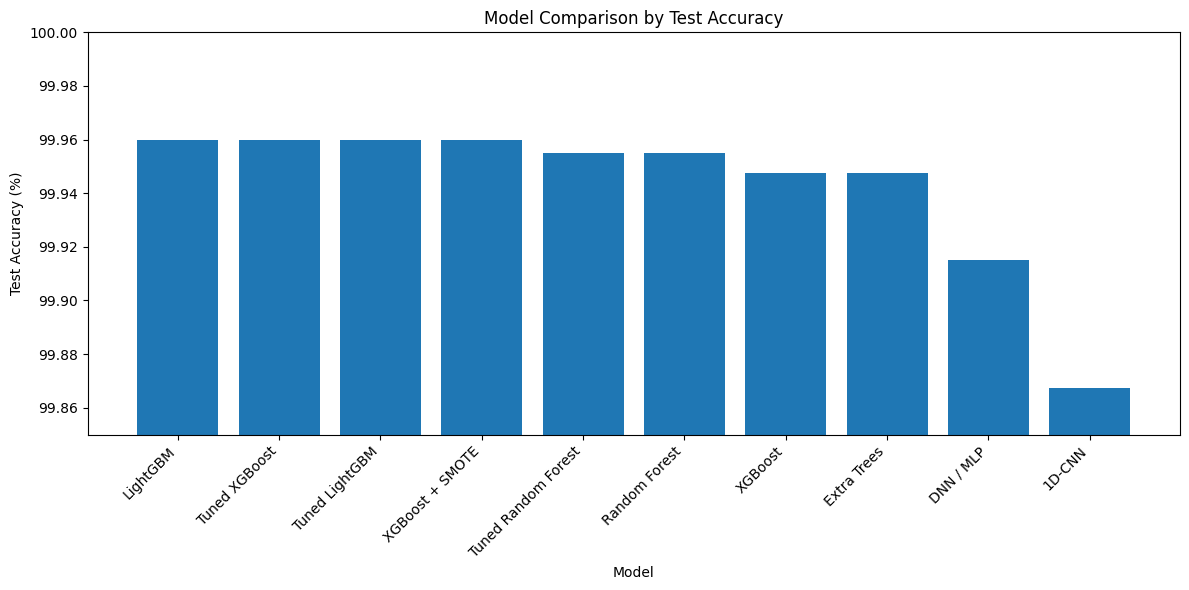

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    final_results_sorted["Model"],
    final_results_sorted["Test Accuracy"] * 100
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Model Comparison by Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(99.85, 100)

plt.tight_layout()
plt.savefig("model_comparison_test_accuracy.png", dpi=300)
plt.show()

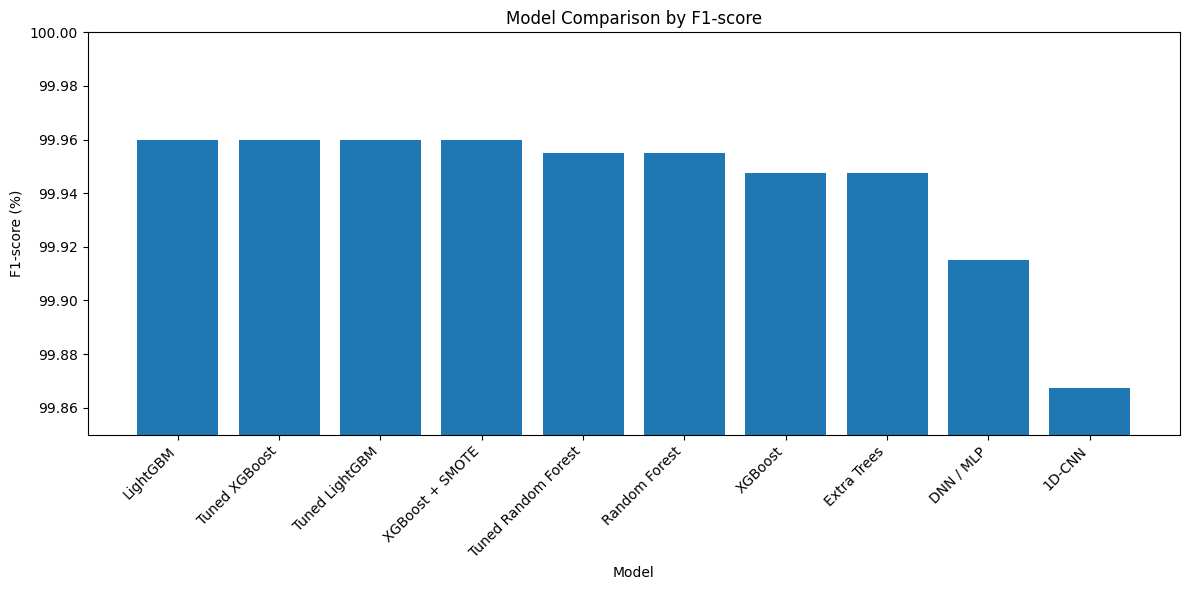

In [74]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results_sorted["Model"],
    final_results_sorted["F1-score"] * 100
)

plt.xlabel("Model")
plt.ylabel("F1-score (%)")
plt.title("Model Comparison by F1-score")
plt.xticks(rotation=45, ha="right")
plt.ylim(99.85, 100)

plt.tight_layout()
plt.savefig("model_comparison_f1_score.png", dpi=300)
plt.show()

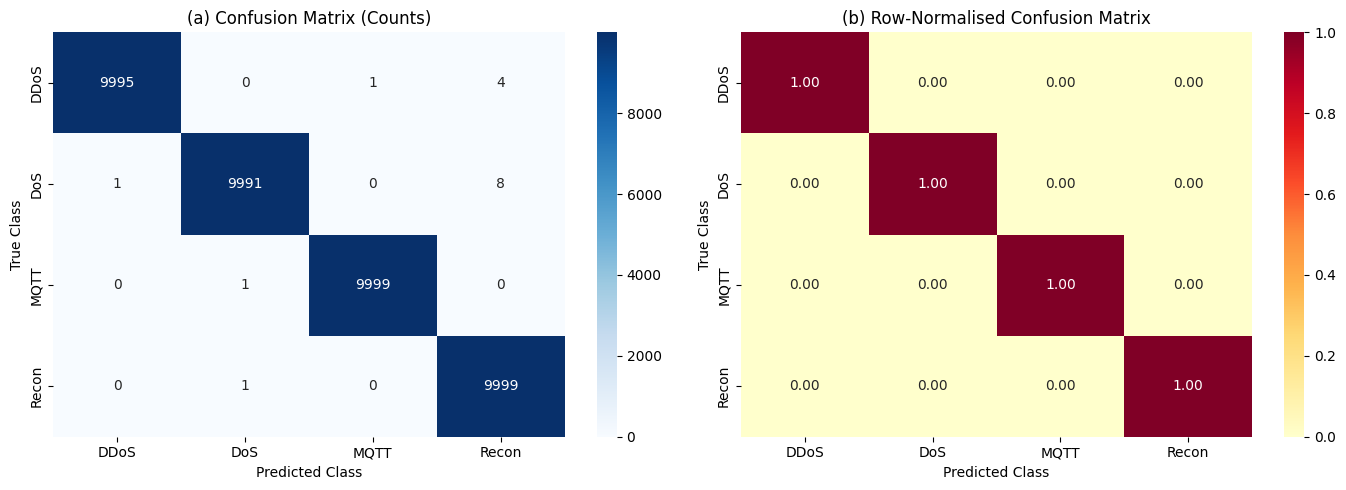

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best_xgb)

cm_normalised = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

class_names = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Confusion matrix counts
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title("(a) Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("True Class")

# (b) Row-normalised confusion matrix
sns.heatmap(
    cm_normalised,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1,
    ax=axes[1]
)

axes[1].set_title("(b) Row-Normalised Confusion Matrix")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("True Class")

plt.tight_layout()
plt.savefig("combined_confusion_matrix_tuned_xgboost.png", dpi=300)
plt.show()

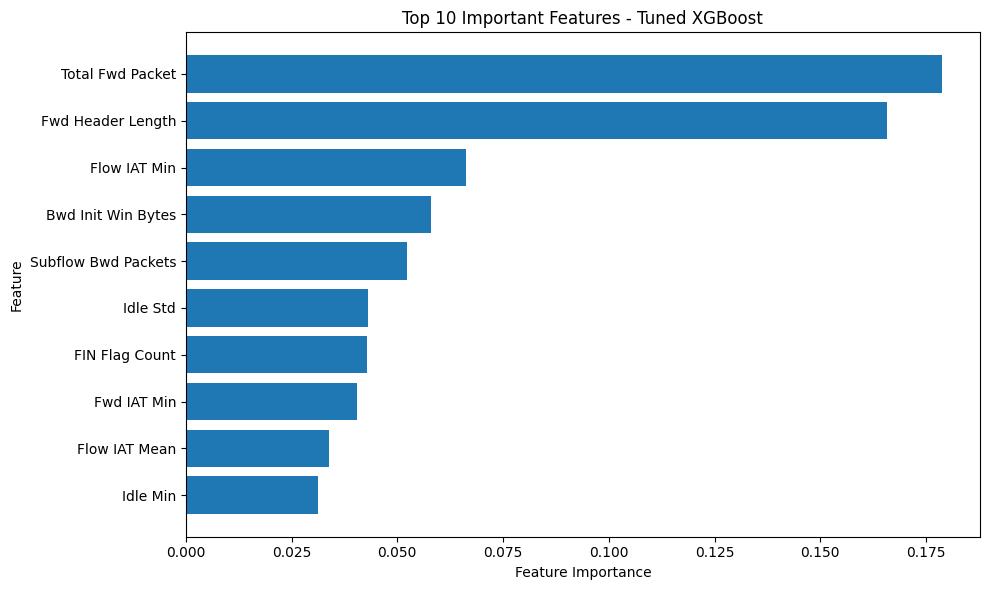

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

# Remove non-real feature/index column
feature_importance = feature_importance[
    feature_importance["Feature"] != "Unnamed: 0"
]

top_10_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_features["Feature"], top_10_features["Importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - Tuned XGBoost")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("top_10_feature_importance_xgboost.png", dpi=300)
plt.show()

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

train_test_all = []

def add_model_result(model_name, model, X_train_data, X_test_data):
    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)

    train_test_all.append({
        "Model": model_name,
        "Training Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred)
    })

# Machine learning models
add_model_result("Random Forest", rf_balanced, X_train, X_test)
add_model_result("XGBoost", xgb_model, X_train, X_test)
add_model_result("Tuned Random Forest", best_rf, X_train, X_test)
add_model_result("Tuned XGBoost", best_xgb, X_train, X_test)
add_model_result("LightGBM", lgbm_model, X_train_lgbm, X_test_lgbm)
add_model_result("Tuned LightGBM", best_lgbm, X_train_lgbm, X_test_lgbm)
add_model_result("Extra Trees", extra_trees_model, X_train, X_test)

# DNN / MLP
y_train_pred_dnn = np.argmax(dnn_model.predict(X_train_dl), axis=1)
y_test_pred_dnn = np.argmax(dnn_model.predict(X_test_dl), axis=1)

train_test_all.append({
    "Model": "DNN / MLP",
    "Training Accuracy": accuracy_score(y_train, y_train_pred_dnn),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_dnn)
})

# 1D-CNN
y_train_pred_cnn = np.argmax(cnn_model.predict(X_train_cnn), axis=1)
y_test_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)

train_test_all.append({
    "Model": "1D-CNN",
    "Training Accuracy": accuracy_score(y_train, y_train_pred_cnn),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_cnn)
})

train_test_all_df = pd.DataFrame(train_test_all)

train_test_all_df["Accuracy Gap"] = (
    train_test_all_df["Training Accuracy"] -
    train_test_all_df["Test Accuracy"]
)

train_test_all_df

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 5s 910us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 906us/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


,Model,Training Accuracy,Test Accuracy,Accuracy Gap
0,Random Forest,1.000000,0.999550,0.000450
1,XGBoost,0.999975,0.999475,0.000500
2,Tuned Random Forest,0.999956,0.999550,0.000406
3,Tuned XGBoost,0.999994,0.999600,0.000394
4,LightGBM,0.999994,0.999600,0.000394
5,Tuned LightGBM,0.999994,0.999600,0.000394
6,Extra Trees,1.000000,0.999475,0.000525
7,DNN / MLP,0.998962,0.999150,-0.000188
8,1D-CNN,0.998731,0.998675,0.000056


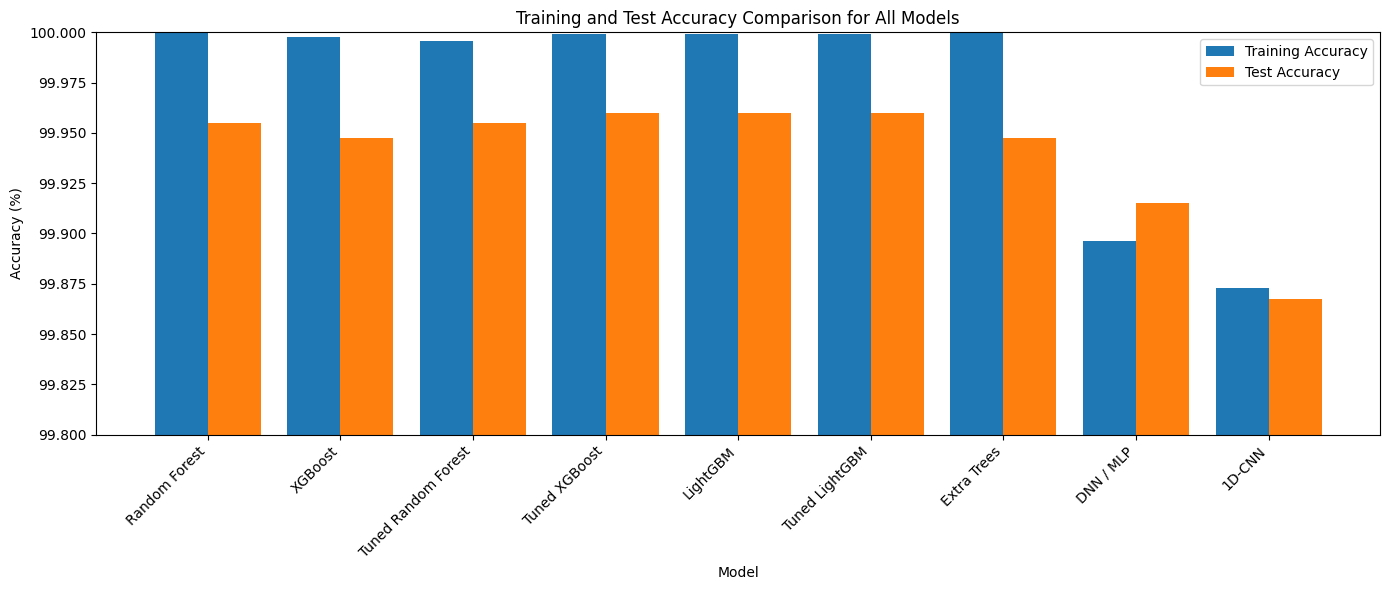

In [78]:
x = range(len(train_test_all_df["Model"]))

plt.figure(figsize=(14, 6))

plt.bar(
    [i - 0.2 for i in x],
    train_test_all_df["Training Accuracy"] * 100,
    width=0.4,
    label="Training Accuracy"
)

plt.bar(
    [i + 0.2 for i in x],
    train_test_all_df["Test Accuracy"] * 100,
    width=0.4,
    label="Test Accuracy"
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Training and Test Accuracy Comparison for All Models")
plt.xticks(x, train_test_all_df["Model"], rotation=45, ha="right")
plt.ylim(99.8, 100)
plt.legend()

plt.tight_layout()
plt.savefig("training_test_accuracy_all_models.png", dpi=300)
plt.show()

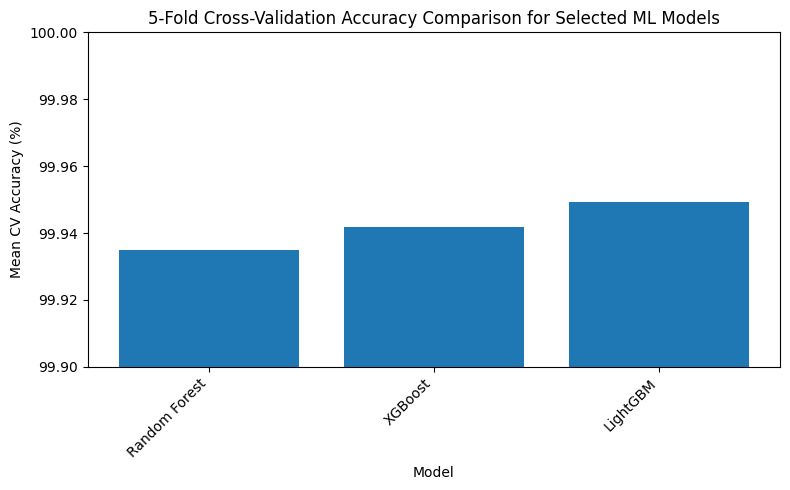

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    cv_summary["Model"],
    cv_summary["Mean CV Accuracy"] * 100
)

plt.xlabel("Model")
plt.ylabel("Mean CV Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy Comparison for Selected ML Models")
plt.xticks(rotation=45, ha="right")
plt.ylim(99.9, 100)

plt.tight_layout()
plt.savefig("cross_validation_selected_ml_models.png", dpi=300)
plt.show()

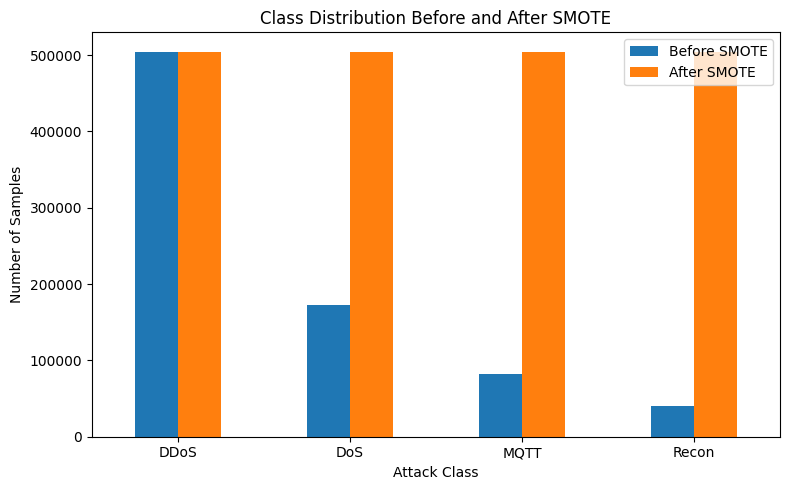

In [80]:
before_smote_counts = pd.Series(
    le_smote.inverse_transform(y_train_smote)
).value_counts()

after_smote_counts = pd.Series(
    le_smote.inverse_transform(y_train_smote_balanced)
).value_counts()

smote_compare = pd.DataFrame({
    "Before SMOTE": before_smote_counts,
    "After SMOTE": after_smote_counts
})

smote_compare.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Attack Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution Before and After SMOTE")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("smote_before_after_distribution.png", dpi=300)
plt.show()

In [81]:
final_results_sorted.to_csv(
    "final_model_results.csv",
    index=False
)

print("Final results saved successfully.")

Final results saved successfully.


In [82]:
final_results_sorted.to_csv(
    "/content/drive/MyDrive/CICIoMT2024/final_model_results.csv",
    index=False
)

print("Final results saved to Google Drive successfully.")

Final results saved to Google Drive successfully.


Deception-Based Honeypot Prototype

In [83]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
from IPython.display import display, Markdown, HTML, clear_output
import ipywidgets as widgets

honeypot_log_file = "honeypot_activity_log.csv"

fake_patient_records = pd.DataFrame({
    "Patient ID": ["P001", "P002", "P003"],
    "Name": ["John Smith", "Mary Johnson", "David Brown"],
    "Heart Rate": [88, 102, 76],
    "Oxygen Level": [96, 91, 98],
    "Status": ["Normal", "Warning", "Normal"]
})

def get_test_sample(X_data, index):
    if hasattr(X_data, "iloc"):
        return X_data.iloc[[index]]
    else:
        return X_data[index:index+1]

def honeypot_decision(sample_index, username, password_attempt):
    sample = get_test_sample(X_test, sample_index)

    probabilities = best_xgb.predict_proba(sample)[0]
    predicted_index = np.argmax(probabilities)
    predicted_attack = le.inverse_transform([predicted_index])[0]
    confidence = probabilities[predicted_index]

    redirect_to_honeypot = True

    log_entry = {
        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Sample Index": sample_index,
        "Username Attempted": username,
        "Password Length": len(password_attempt),
        "Predicted Attack": predicted_attack,
        "Confidence": round(float(confidence), 4),
        "Action": "Redirected to honeypot" if redirect_to_honeypot else "Allowed"
    }

    log_df = pd.DataFrame([log_entry])

    if os.path.exists(honeypot_log_file):
        log_df.to_csv(honeypot_log_file, mode="a", header=False, index=False)
    else:
        log_df.to_csv(honeypot_log_file, index=False)

    display(Markdown("## ML-Based Deception Decision"))
    display(Markdown(f"**Predicted attack class:** `{predicted_attack}`"))
    display(Markdown(f"**Model confidence:** `{confidence:.4f}`"))
    display(Markdown("**Decision:** Suspicious traffic redirected to honeypot."))

    display(Markdown("## Decoy Healthcare Portal"))
    display(HTML(fake_patient_records.to_html(index=False)))

    display(Markdown("## Latest Honeypot Logs"))
    display(pd.read_csv(honeypot_log_file).tail(5))

In [84]:
sample_index_widget = widgets.IntSlider(
    value=0,
    min=0,
    max=len(X_test)-1,
    step=1,
    description="Sample:"
)

username_widget = widgets.Text(
    value="unknown_user",
    description="Username:"
)

password_widget = widgets.Password(
    value="test123",
    description="Password:"
)

button = widgets.Button(
    description="Simulate Access",
    button_style="danger"
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        honeypot_decision(
            sample_index_widget.value,
            username_widget.value,
            password_widget.value
        )

button.on_click(on_button_click)

display(sample_index_widget, username_widget, password_widget, button, output)

IntSlider(value=0, description='Sample:', max=39999)

Text(value='unknown_user', description='Username:')

Password(description='Password:')

Button(button_style='danger', description='Simulate Access', style=ButtonStyle())

Output()